# Spinoff Index Arbitrage — EDA & Statistical Testing

Strategy context (from README):
- **Entry:** Short the spin-off at first trading day close when inclusion-related flow signals trigger
- **Hedge:** Long broad equity index futures to target beta neutrality  
- **Exit:** Deletion confirmation, rebalance date, time-stop (21–60 days), or stop-loss
- **Position sizing:** Deletion probability model using eligibility + liquidity features

This notebook covers steps 3–4 of the project timeline:
1. Data QC — verify spinoff events match WRDS/CRSP data
2. Event study — abnormal returns around spinoff effective date
3. Forced-flow feature — passive AUM × index weight
4. Deletion signal — what predicts parent removal from S&P 500?
5. Signal construction prep — feature distributions and correlations

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy import stats
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.3f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RAW_DIR = Path('data/raw')
CLEAN_DIR = Path('data/clean')
print('Paths OK')

Paths OK


## 1. Load Data

In [2]:
# Spinoff events (Bloomberg + WRDS metadata + forced-flow features)
events = pd.read_csv(CLEAN_DIR / 'spinoff_events_merged.csv',
                     parse_dates=['announce_date', 'effective_date',
                                  'sp500_start', 'sp500_end'])
print(f'Spinoff events: {len(events)} rows')
events.head()

Spinoff events: 30 rows


,parent_name,parent_ticker,permno,gvkey,spinoff_name,spinoff_ticker,spinoff_ratio,announce_date,effective_date,company_name_wrds,ticker_wrds,sp500_start,sp500_end,still_active,in_sp500_at_spinoff,naics,parent_mktcap_usd,sp500_total_mktcap_usd,parent_index_weight,passive_aum_usd,forced_flow_usd,parent_adv_usd,forced_flow_adv
0,McKesson Corp,MCK,10516,"1,722.000",PF2 SpinCo Inc,1784039D,11.4086: 1,2020-02-10,2020-03-10,ARCHER DANIELS MIDLAND CO,ADM,1981-07-30,2024-12-31,False,True,"311,221.000","19,693,411,100.000","24,597,239,235,908.711",0.001,"1,437,588,900,000.000","1,150,984,016.091","149,510,168.890",7.698
1,Howmet Aerospace Inc,HWM,14543,"23,167.000",Arconic Corp,ARNC,1 per 4,2024-10-30,2020-04-01,NaN,NaN,NaT,NaT,NaN,False,NaN,"293,361,200.000","23,103,020,343,860.480",0.000,"1,260,266,900,000.000","16,002,817.147","2,393,281.219",6.687
2,RTX Corp,RTX,12431,"5,959.000",Carrier Global Corp,CARR,1 per 1,2018-11-26,2020-04-03,TRANE TECHNOLOGIES PLC,TT,2010-11-17,2024-12-31,False,True,"333,413.000","19,753,906,860.000","22,595,036,133,384.637",0.001,"1,260,266,900,000.000","1,101,799,298.500","261,253,480.970",4.217
3,RTX Corp,RTX,12431,"5,959.000",Otis Worldwide Corp,OTIS,1 per 2,2018-11-26,2020-04-03,TRANE TECHNOLOGIES PLC,TT,2010-11-17,2024-12-31,False,True,"333,413.000","19,753,906,860.000","22,595,036,133,384.637",0.001,"1,260,266,900,000.000","1,101,799,298.500","261,253,480.970",4.217
4,Ecolab Inc,ECL,70578,"4,213.000",ChampionX Holding Inc,1695496D,24.6667: 1,2019-02-04,2020-06-04,ECOLAB INC,ECL,1989-01-12,2024-12-31,False,True,"325,611.000","63,873,153,720.000","28,065,829,749,247.695",0.002,"1,474,625,200,000.000","3,356,001,334.025","1,262,645,512.329",2.658


In [3]:
# CRSP daily prices (parents + current S&P 500 constituents)
crsp = pd.read_parquet(RAW_DIR / 'crsp_daily.parquet')
print(f'CRSP daily: {len(crsp):,} rows, {crsp["permno"].nunique()} permnos')
print(f'Date range: {crsp["date"].min().date()} → {crsp["date"].max().date()}')

# Index returns
idx_ret = pd.read_parquet(RAW_DIR / 'crsp_index_returns.parquet')

# S&P 500 constituents (via crsp.msp500list — permno-based, 2010-present)
constituents = pd.read_parquet(RAW_DIR / 'sp500_constituents_pit.parquet')
id_col = 'permno' if 'permno' in constituents.columns else 'gvkey'
print(f'\nConstituents: {len(constituents)} membership records, '
      f'{constituents[id_col].nunique()} unique companies')
print(f'Date range: {constituents["start_date"].min().date()} → '
      f'{constituents["end_date"].max().date()}')

# Passive AUM (if available)
aum_path = RAW_DIR / 'sp500_passive_aum.parquet'
if aum_path.exists():
    passive_aum = pd.read_parquet(aum_path)
    latest = passive_aum.sort_values('date').iloc[-1]
    print(f'\nPassive AUM: {len(passive_aum)} monthly obs | '
          f'latest ${latest["total_aum_billions"]:.0f}B ({latest["date"].date()})')
else:
    passive_aum = None
    print('\n[!] Passive AUM not available yet')

CRSP daily: 2,519,394 rows, 826 permnos
Date range: 2010-01-04 → 2024-12-31

Constituents: 828 membership records, 817 unique companies
Date range: 1925-12-31 → 2024-12-31

Passive AUM: 195 monthly obs | latest $4401B (2026-03-31)


## 2. Data QC — Verify Spinoff ↔ WRDS Match

In [4]:
# Coverage check: which parents have CRSP price data?
crsp_permnos = set(crsp['permno'].unique())
events['has_price_data'] = events['permno'].isin(crsp_permnos)

print('=== Coverage Summary ===')
print(f"Total events:          {len(events)}")
if 'gvkey' in events.columns:
    print(f"Has WRDS gvkey:        {events['gvkey'].notna().sum()}")
print(f"Has CRSP price data:   {events['has_price_data'].sum()}")
print(f"In S&P 500 at spinoff: {events['in_sp500_at_spinoff'].sum()}")
print()

missing_prices = events[~events['has_price_data']][['parent_name','parent_ticker','permno','effective_date']]
if len(missing_prices):
    print(f'Events missing CRSP prices ({len(missing_prices)}):')
    print(missing_prices.to_string(index=False))

=== Coverage Summary ===
Total events:          30
Has WRDS gvkey:        28
Has CRSP price data:   30
In S&P 500 at spinoff: 21



In [5]:
# For events WITH price data: verify price exists around each effective date
def check_price_around_date(permno, eff_date, window_days=5):
    if pd.isna(permno):
        return False
    p = crsp[(crsp['permno'] == int(permno)) &
              (crsp['date'] >= eff_date - pd.Timedelta(days=window_days)) &
              (crsp['date'] <= eff_date + pd.Timedelta(days=window_days))]
    return len(p) > 0

events_with_prices = events[events['has_price_data']].copy()
events_with_prices['price_near_event'] = events_with_prices.apply(
    lambda r: check_price_around_date(r['permno'], r['effective_date']), axis=1
)

print('Price data within ±5 days of effective date:')
print(events_with_prices[['parent_ticker', 'effective_date', 'price_near_event']].to_string(index=False))

Price data within ±5 days of effective date:
parent_ticker effective_date  price_near_event
          MCK     2020-03-10              True
          HWM     2020-04-01              True
          RTX     2020-04-03              True
          RTX     2020-04-03              True
          ECL     2020-06-04              True
          OXY     2020-07-02              True
          FTV     2020-10-09              True
          PFE     2020-11-17              True
          MRK     2021-06-03              True
          DTE     2021-07-01              True
           IP     2021-10-01              True
         DELL     2021-11-02              True
          IBM     2021-11-04              True
            O     2021-11-15              True
          EXC     2022-02-02              True
          ZBH     2022-03-01              True
          BDX     2022-04-01              True
            T     2022-04-11              True
           GE     2023-01-04              True
           LH  

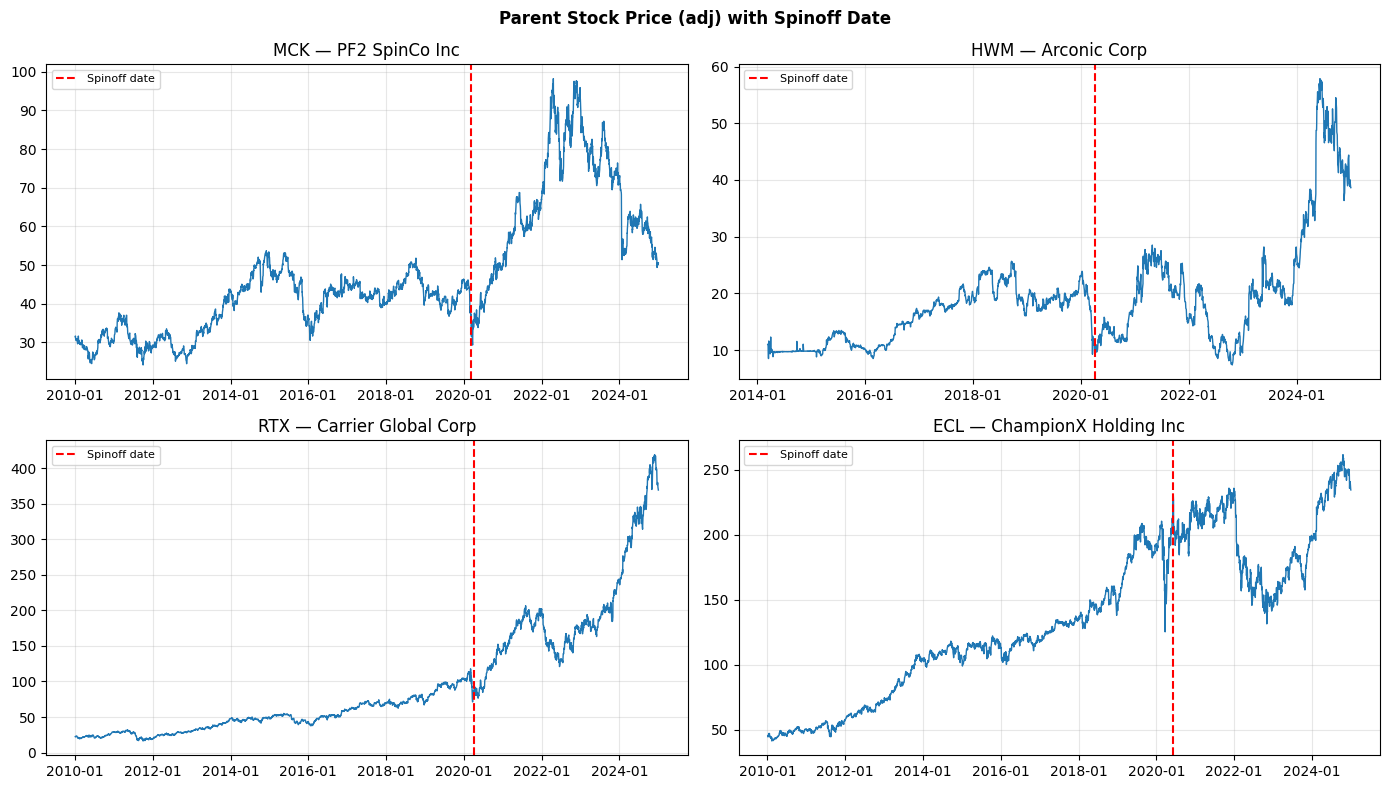

In [6]:
# Sample price series for a few parents — visual sanity check
sample_events = events[events['has_price_data']].drop_duplicates('permno').head(4)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (_, ev) in zip(axes.flat, sample_events.iterrows()):
    p = crsp[crsp['permno'] == ev['permno']].sort_values('date')
    ax.plot(p['date'], p['adj_prc'], lw=1)
    ax.axvline(ev['effective_date'], color='red', linestyle='--', label='Spinoff date')
    ax.set_title(f"{ev['parent_ticker']} — {ev['spinoff_name'][:30]}")
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.legend(fontsize=8)
plt.suptitle('Parent Stock Price (adj) with Spinoff Date', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Event Study — Abnormal Returns Around Spinoff Date

Market-adjusted return: $AR_t = R_{i,t} - R_{m,t}$  
Cumulative abnormal return: $CAR_{[t_1, t_2]} = \sum_{t=t_1}^{t_2} AR_t$

In [7]:
def get_event_window(permno, eff_date, crsp_df, idx_ret_df, pre=60, post=60):
    """Return daily (t, ret, ret_mkt_adj) for ±pre/post trading days around eff_date."""
    cal_days = int((pre + post) * 1.6)
    parent = crsp_df[crsp_df['permno'] == int(permno)].copy()
    window = parent[
        (parent['date'] >= eff_date - pd.Timedelta(days=cal_days)) &
        (parent['date'] <= eff_date + pd.Timedelta(days=cal_days))
    ].merge(idx_ret_df[['date', 'sprtrn']], on='date', how='left')
    
    window = window.sort_values('date').reset_index(drop=True)
    eff_idx = window['date'].searchsorted(eff_date)
    window['t'] = range(-eff_idx, len(window) - eff_idx)
    window['ret_mkt_adj'] = window['ret'] - window['sprtrn']
    return window[abs(window['t']) <= max(pre, post)]


# Build event windows for all parents with CRSP data
event_windows = []
for _, ev in events[events['has_price_data']].iterrows():
    w = get_event_window(ev['permno'], ev['effective_date'], crsp, idx_ret)
    if len(w) == 0:
        continue
    w['parent_ticker'] = ev['parent_ticker']
    w['spinoff_name'] = ev['spinoff_name']
    w['effective_date'] = ev['effective_date']
    w['permno'] = ev['permno']
    event_windows.append(w)

if event_windows:
    all_windows = pd.concat(event_windows, ignore_index=True)
    print(f'Event windows built: {all_windows["parent_ticker"].nunique()} parents')
else:
    print('[!] No event windows — run repull_data.py to fetch parent CRSP prices')
    all_windows = pd.DataFrame()

Event windows built: 25 parents


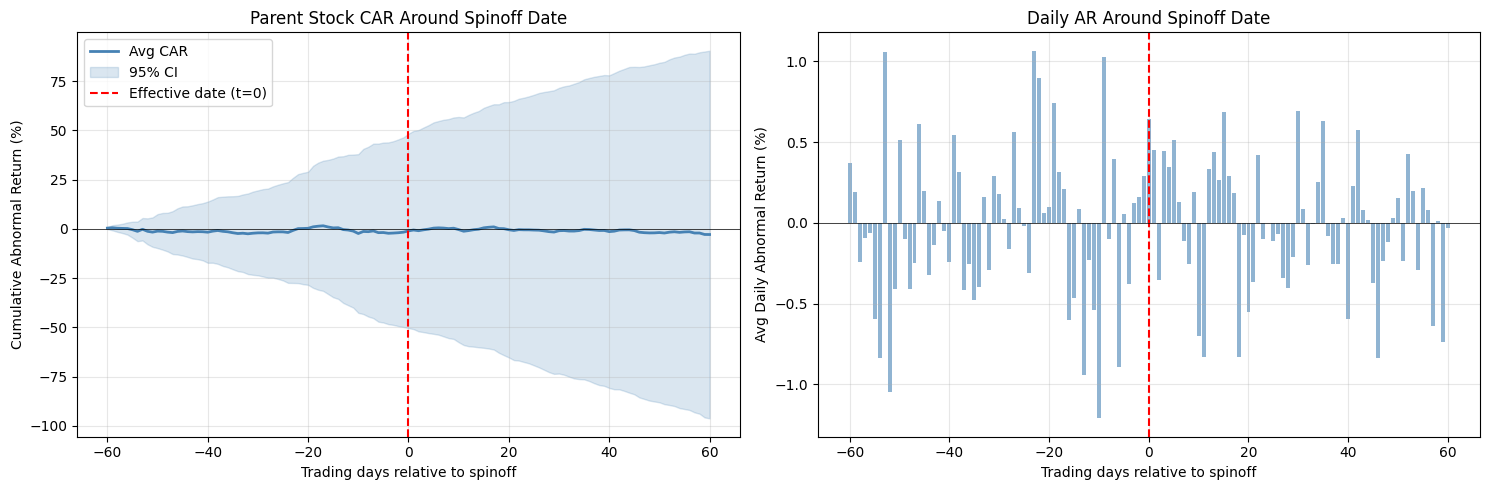

Average CAR[0, +20]: 1.22%
Average CAR[-10, 0]: 0.11%


In [8]:
if len(all_windows):
    # Average CAR across events
    car = (
        all_windows.groupby('t')['ret_mkt_adj']
        .agg(['mean', 'sem', 'count'])
        .reset_index()
    )
    car['cum_mean'] = car['mean'].cumsum()
    car['ci_upper'] = car['cum_mean'] + 1.96 * car['sem'].cumsum()
    car['ci_lower'] = car['cum_mean'] - 1.96 * car['sem'].cumsum()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Cumulative Abnormal Return
    ax1.plot(car['t'], car['cum_mean'] * 100, lw=2, color='steelblue', label='Avg CAR')
    ax1.fill_between(car['t'], car['ci_lower'] * 100, car['ci_upper'] * 100,
                     alpha=0.2, color='steelblue', label='95% CI')
    ax1.axvline(0, color='red', linestyle='--', label='Effective date (t=0)')
    ax1.axhline(0, color='black', lw=0.5)
    ax1.set_xlabel('Trading days relative to spinoff')
    ax1.set_ylabel('Cumulative Abnormal Return (%)')
    ax1.set_title('Parent Stock CAR Around Spinoff Date')
    ax1.legend()

    # Daily average AR
    ax2.bar(car['t'], car['mean'] * 100, color='steelblue', alpha=0.6, width=0.8)
    ax2.axvline(0, color='red', linestyle='--')
    ax2.axhline(0, color='black', lw=0.5)
    ax2.set_xlabel('Trading days relative to spinoff')
    ax2.set_ylabel('Avg Daily Abnormal Return (%)')
    ax2.set_title('Daily AR Around Spinoff Date')

    plt.tight_layout()
    plt.show()
    print(f"Average CAR[0, +20]: {car[car['t'].between(0, 20)]['mean'].sum() * 100:.2f}%")
    print(f"Average CAR[-10, 0]: {car[car['t'].between(-10, 0)]['mean'].sum() * 100:.2f}%")

In [9]:
if len(all_windows):
    # t-test: is CAR[0, +20] significantly different from zero?
    post_20_cars = (
        all_windows[all_windows['t'].between(1, 20)]
        .groupby(['parent_ticker', 'effective_date'])['ret_mkt_adj']
        .sum()
        .reset_index(name='car_20')
    )

    pre_10_cars = (
        all_windows[all_windows['t'].between(-10, -1)]
        .groupby(['parent_ticker', 'effective_date'])['ret_mkt_adj']
        .sum()
        .reset_index(name='car_neg10')
    )

    t_stat, p_val = stats.ttest_1samp(post_20_cars['car_20'].dropna(), 0)
    print('=== t-test: CAR[+1, +20] = 0? ===')
    print(f'N events:      {len(post_20_cars)}')
    print(f'Mean CAR:      {post_20_cars["car_20"].mean() * 100:.2f}%')
    print(f'Std CAR:       {post_20_cars["car_20"].std() * 100:.2f}%')
    print(f't-statistic:   {t_stat:.3f}')
    print(f'p-value:       {p_val:.4f}')
    print(f'Significant:   {"YES" if p_val < 0.05 else "NO"} (α=0.05)')

    print()
    t_stat2, p_val2 = stats.ttest_1samp(pre_10_cars['car_neg10'].dropna(), 0)
    print('=== t-test: CAR[-10, -1] = 0? ===')
    print(f'Mean CAR:      {pre_10_cars["car_neg10"].mean() * 100:.2f}%')
    print(f't-statistic:   {t_stat2:.3f}')
    print(f'p-value:       {p_val2:.4f}')

=== t-test: CAR[+1, +20] = 0? ===
N events:      24
Mean CAR:      0.60%
Std CAR:       8.71%
t-statistic:   0.340
p-value:       0.7373
Significant:   NO (α=0.05)

=== t-test: CAR[-10, -1] = 0? ===
Mean CAR:      -0.54%
t-statistic:   -0.528
p-value:       0.6019


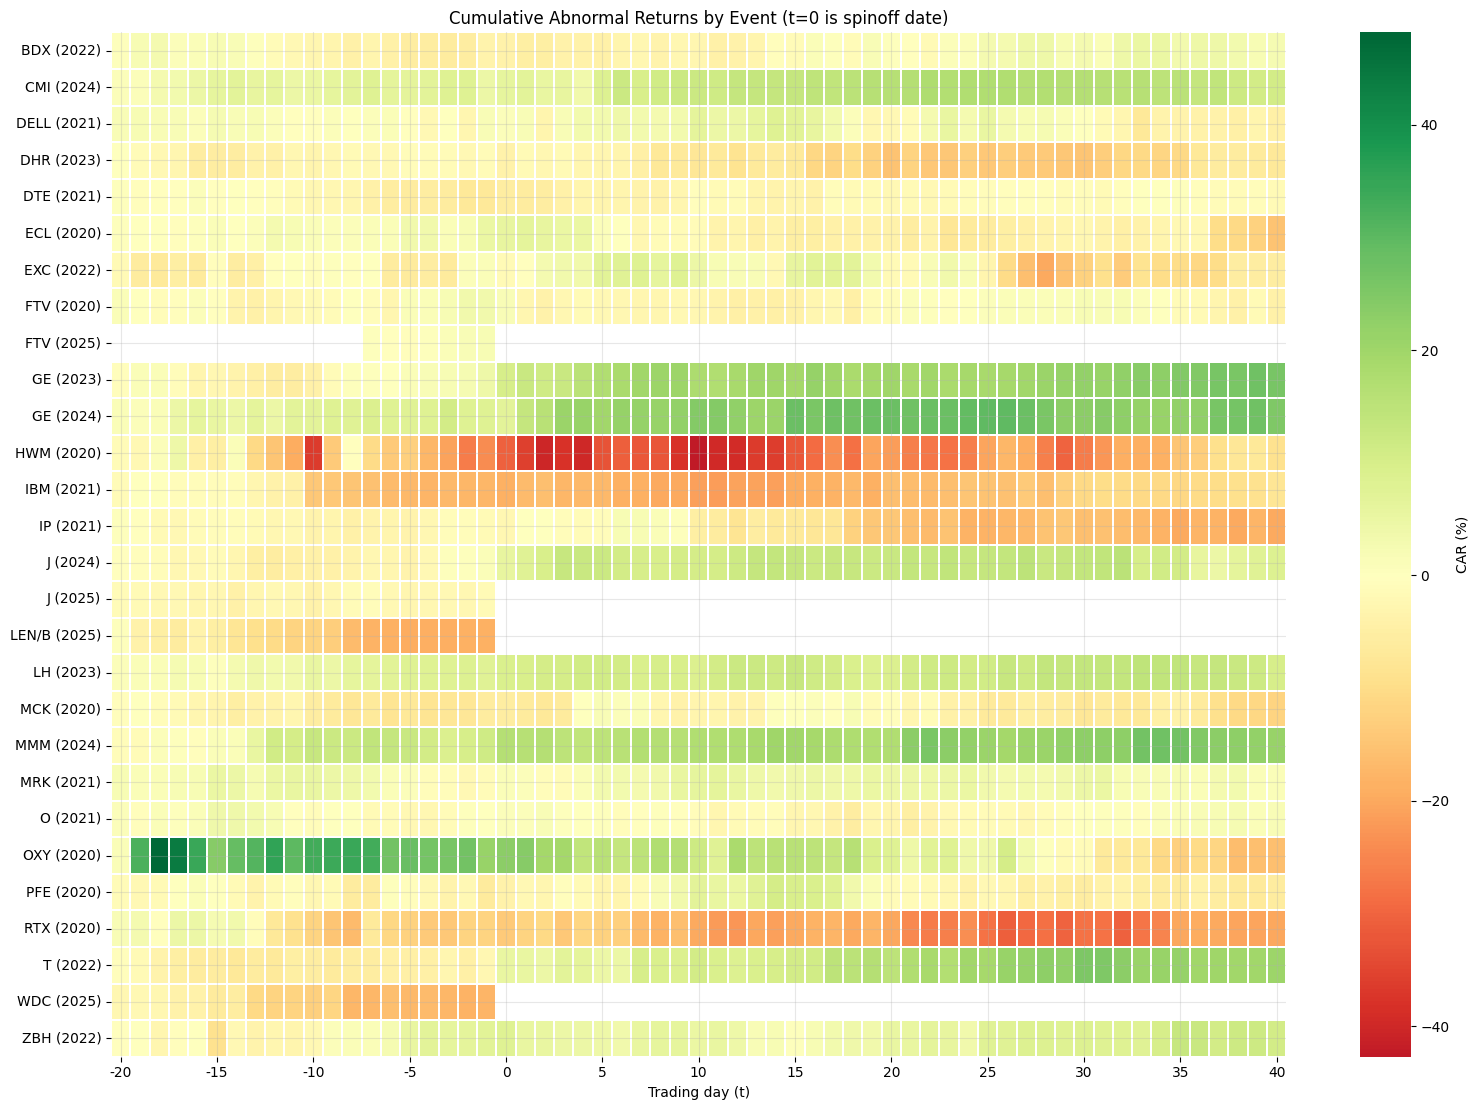

In [10]:
if len(all_windows):
    # Individual event CARs — heatmap
    car_matrix = (
        all_windows[all_windows['t'].between(-20, 40)]
        .pivot_table(index=['parent_ticker', 'effective_date'],
                     columns='t', values='ret_mkt_adj', aggfunc='mean')
        .cumsum(axis=1)
    )
    car_matrix.index = [f"{t} ({d.year})" for t, d in car_matrix.index]

    fig, ax = plt.subplots(figsize=(16, max(6, len(car_matrix) * 0.4)))
    sns.heatmap(car_matrix * 100, center=0, cmap='RdYlGn', ax=ax,
                xticklabels=5, cbar_kws={'label': 'CAR (%)'},
                linewidths=0.1)
    ax.set_title('Cumulative Abnormal Returns by Event (t=0 is spinoff date)')
    ax.set_xlabel('Trading day (t)')
    plt.tight_layout()
    plt.show()

## 4. Passive AUM & Forced-Flow Feature

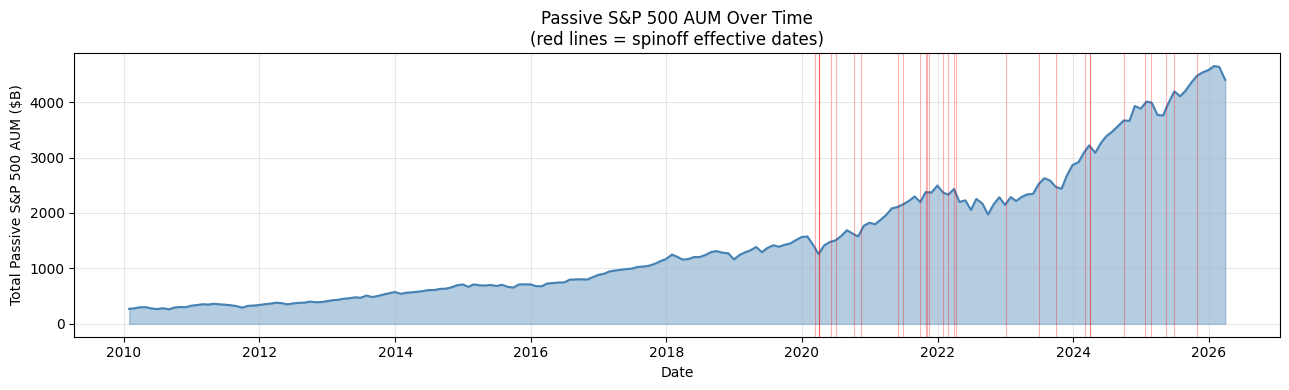

In [11]:
if passive_aum is not None:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.fill_between(passive_aum['date'], passive_aum['total_aum_billions'],
                    alpha=0.4, color='steelblue')
    ax.plot(passive_aum['date'], passive_aum['total_aum_billions'],
            color='steelblue', lw=1.5)

    # mark spinoff events
    for _, ev in events.iterrows():
        ax.axvline(ev['effective_date'], color='red', alpha=0.3, lw=0.8)

    ax.set_xlabel('Date')
    ax.set_ylabel('Total Passive S&P 500 AUM ($B)')
    ax.set_title('Passive S&P 500 AUM Over Time\n(red lines = spinoff effective dates)')
    plt.tight_layout()
    plt.show()
else:
    print('[!] Run pull_etf_aum.py to get passive AUM data')

In [12]:
# Forced-flow feature distribution
ff_cols = ['parent_ticker', 'effective_date', 'parent_index_weight',
           'passive_aum_usd', 'forced_flow_usd', 'forced_flow_adv']
available_ff = [c for c in ff_cols if c in events.columns]
ff_data = events[available_ff].dropna(subset=['forced_flow_usd'] if 'forced_flow_usd' in available_ff else ['parent_index_weight'])

if len(ff_data):
    print(f'Events with forced-flow estimates: {len(ff_data)}')
    display(ff_data.describe())
else:
    print('[!] No forced-flow estimates yet — need full CRSP + AUM data')
    print('    Run: python repull_data.py')

Events with forced-flow estimates: 30


,effective_date,parent_index_weight,passive_aum_usd,forced_flow_usd,forced_flow_adv
count,30,30.000,30.000,30.000,30.000
mean,2022-07-27 20:48:00,0.002,"2,493,530,966,666.667","3,667,040,608.328",9.698
min,2020-03-10 00:00:00,0.000,"1,260,266,900,000.000","1,447,301.533",0.995
25%,2021-01-05 12:00:00,0.000,"1,748,935,400,000.000","1,114,095,477.898",4.688
50%,2022-02-15 12:00:00,0.001,"2,376,037,700,000.000","1,494,111,371.888",7.706
75%,2024-03-26 00:00:00,0.003,"3,188,372,325,000.000","5,373,510,844.558",11.305
max,2025-10-30 00:00:00,0.006,"4,356,242,300,000.000","13,215,318,432.654",46.509
std,NaN,0.002,"908,780,787,457.772","4,182,270,472.070",8.205


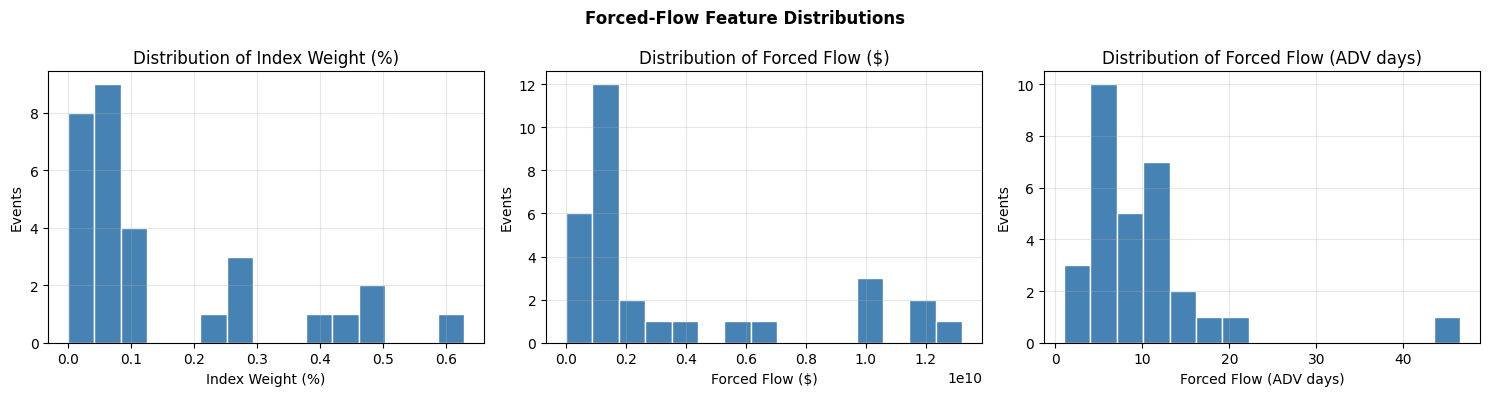

In [13]:
if 'forced_flow_adv' in events.columns and events['forced_flow_adv'].notna().any():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    events['parent_index_weight_pct'] = events['parent_index_weight'] * 100
    for ax, col, label in zip(axes,
        ['parent_index_weight_pct', 'forced_flow_usd', 'forced_flow_adv'],
        ['Index Weight (%)', 'Forced Flow ($)', 'Forced Flow (ADV days)']):
        d = events[col].dropna()
        ax.hist(d, bins=15, edgecolor='white', color='steelblue')
        ax.set_xlabel(label)
        ax.set_ylabel('Events')
        ax.set_title(f'Distribution of {label}')

    plt.suptitle('Forced-Flow Feature Distributions', fontweight='bold')
    plt.tight_layout()
    plt.show()

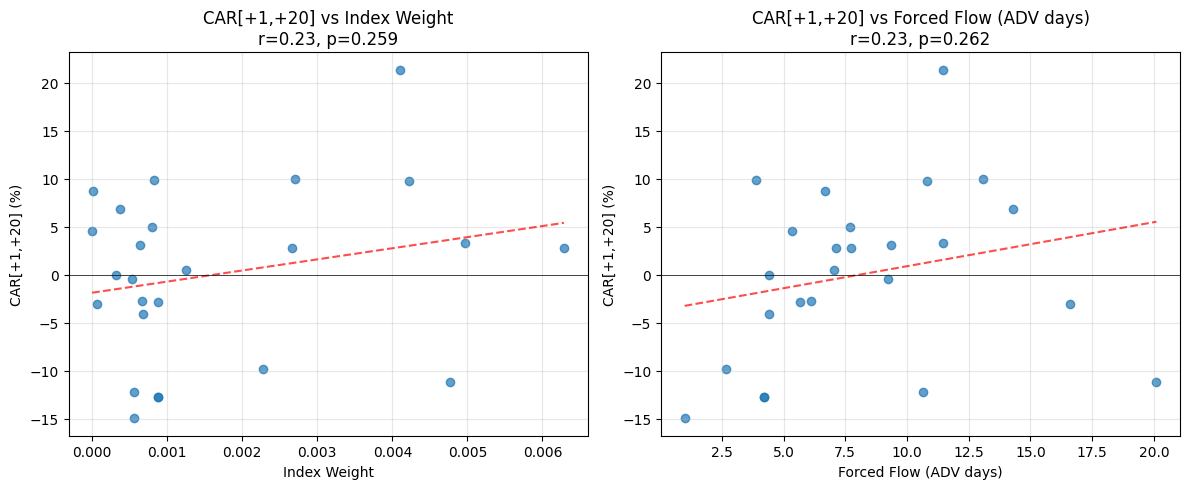

In [14]:
# Correlation: does higher forced-flow predict worse post-event returns?
if 'forced_flow_adv' in events.columns and len(all_windows):
    post_cars = (
        all_windows[all_windows['t'].between(1, 20)]
        .groupby(['permno', 'effective_date'])['ret_mkt_adj']
        .sum()
        .reset_index(name='car_20')
    )
    post_cars['permno'] = post_cars['permno'].astype('Int64')
    combined = post_cars.merge(
        events[['permno', 'effective_date', 'parent_index_weight',
                'forced_flow_adv', 'forced_flow_usd']],
        on=['permno', 'effective_date'], how='inner'
    ).dropna()

    if len(combined) > 2:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        for ax, xcol, xlabel in zip(axes,
            ['parent_index_weight', 'forced_flow_adv'],
            ['Index Weight', 'Forced Flow (ADV days)']):
            ax.scatter(combined[xcol], combined['car_20'] * 100, alpha=0.7)
            if len(combined) > 2:
                m, b = np.polyfit(combined[xcol].dropna(), combined.loc[combined[xcol].notna(), 'car_20'] * 100, 1)
                x_line = np.linspace(combined[xcol].min(), combined[xcol].max(), 50)
                ax.plot(x_line, m * x_line + b, 'r--', alpha=0.7)
                r, p = stats.pearsonr(combined[xcol].dropna(), combined.loc[combined[xcol].notna(), 'car_20'])
                ax.set_title(f'CAR[+1,+20] vs {xlabel}\nr={r:.2f}, p={p:.3f}')
            ax.set_xlabel(xlabel)
            ax.set_ylabel('CAR[+1,+20] (%)')
            ax.axhline(0, color='black', lw=0.5)
        plt.tight_layout()
        plt.show()
    else:
        print('[!] Not enough overlapping data for forced-flow vs CAR correlation')

## 5. Deletion Signal — What Predicts Parent Removal from S&P 500?

In [15]:
# Build deletion outcome: did the parent leave the S&P 500 within 1 year of spinoff?
# Constituents are permno-based (msp500list); fall back to gvkey if old schema.
_const_key = 'permno' if 'permno' in constituents.columns else 'gvkey'

def check_deleted(row, constituents_df, window_days=365):
    """Returns True if parent left S&P 500 within window_days after spinoff."""
    join_val = row.get(_const_key)
    if pd.isna(join_val):
        return None
    parent_memberships = constituents_df[constituents_df[_const_key] == join_val]
    if parent_memberships.empty:
        return None
    eff = row['effective_date']
    deleted_records = parent_memberships[
        (parent_memberships['end_date'] >= eff) &
        (parent_memberships['end_date'] <= eff + pd.Timedelta(days=window_days)) &
        (~parent_memberships['still_active'])
    ]
    return len(deleted_records) > 0

events['deleted_within_1yr'] = events.apply(
    check_deleted, axis=1, constituents_df=constituents
)

deletion_counts = events['deleted_within_1yr'].value_counts(dropna=False)
print('Parent deleted from S&P 500 within 1 year of spinoff:')
print(deletion_counts)
print(f'\nDeletion rate: {deletion_counts.get(True, 0) / deletion_counts.sum():.1%}')

Parent deleted from S&P 500 within 1 year of spinoff:
deleted_within_1yr
False    21
None      5
True      4
Name: count, dtype: int64

Deletion rate: 13.3%


In [16]:
# Feature: mktcap drop from spinoff (parent loses spun-off subsidiary's value)
# Proxy: |price change| around effective date from CRSP
def get_price_drop(permno, eff_date, crsp_df, pre_days=5, post_days=5):
    if pd.isna(permno):
        return None
    p = crsp_df[(crsp_df['permno'] == int(permno))].sort_values('date')
    pre = p[p['date'] < eff_date].tail(pre_days)
    post = p[p['date'] >= eff_date].head(post_days)
    if pre.empty or post.empty:
        return None
    return (post['adj_prc'].mean() / pre['adj_prc'].mean()) - 1

events['price_drop_at_spinoff'] = events.apply(
    lambda r: get_price_drop(r['permno'], r['effective_date'], crsp), axis=1
)

# Summary of price drop by deletion outcome
if events['deleted_within_1yr'].notna().sum() > 0:
    print('Price drop at spinoff by deletion outcome:')
    print(events.groupby('deleted_within_1yr')['price_drop_at_spinoff']
          .agg(['mean', 'count']).round(4))

Price drop at spinoff by deletion outcome:
                    mean  count
deleted_within_1yr             
False              0.018     17
True               0.050      4


In [17]:
# Spinoff ratio → implied parent mktcap reduction
# Parse spinoff_ratio: "1 per 4" means 1 spinoff share per 4 parent shares
def parse_spinoff_ratio(ratio_str):
    """Returns spinoff shares per parent share."""
    if pd.isna(ratio_str):
        return None
    s = str(ratio_str).strip()
    # formats: "1 per 4", "2 per 5", ".4406  : 1", "11.4086: 1", "1 per 1"
    try:
        if 'per' in s.lower():
            parts = s.lower().replace('per', '/').split('/')
            return float(parts[0].strip()) / float(parts[1].strip())
        elif ':' in s:
            parts = s.split(':')
            return float(parts[0].strip()) / float(parts[1].strip())
    except Exception:
        return None
    return None

events['spinoff_shares_per_parent'] = events['spinoff_ratio'].apply(parse_spinoff_ratio)

print('Spinoff ratio distribution:')
print(events[['spinoff_ratio', 'spinoff_shares_per_parent']].dropna().to_string(index=False))

Spinoff ratio distribution:
spinoff_ratio  spinoff_shares_per_parent
   11.4086: 1                     11.409
      1 per 4                      0.250
      1 per 1                      1.000
      1 per 2                      0.500
   24.6667: 1                     24.667
      1 per 8                      0.125
      2 per 5                      0.400
   .1241  : 1                      0.124
     1 per 10                      0.100
      1 per 2                      0.500
     1 per 11                      0.091
   .4406  : 1                      0.441
      1 per 5                      0.200
     1 per 10                      0.100
      1 per 3                      0.333
     1 per 10                      0.100
      1 per 5                      0.200
      1 per 1                      1.000
      1 per 3                      0.333
      1 per 1                      1.000
      1 per 3                      0.333
   12.0298: 1                     12.030
      1 per 4                

In [18]:
# S&P 500 constituent tenure at spinoff date
def get_tenure_years(row):
    if pd.isna(row.get('sp500_start')) or pd.isna(row.get('effective_date')):
        return None
    return (row['effective_date'] - row['sp500_start']).days / 365.25

events['sp500_tenure_years'] = events.apply(get_tenure_years, axis=1)

# Announce-to-effective lag (months)
events['announce_lag_days'] = (events['effective_date'] - events['announce_date']).dt.days

# Summary feature table
feature_cols = ['parent_ticker', 'effective_date', 'spinoff_shares_per_parent',
                'sp500_tenure_years', 'announce_lag_days', 'price_drop_at_spinoff',
                'parent_index_weight', 'forced_flow_adv', 'deleted_within_1yr']
feat = events[[c for c in feature_cols if c in events.columns]]
print('Feature table:')
display(feat)

Feature table:


,parent_ticker,effective_date,spinoff_shares_per_parent,sp500_tenure_years,announce_lag_days,price_drop_at_spinoff,parent_index_weight,forced_flow_adv,deleted_within_1yr
0,MCK,2020-03-10,11.409,38.612,29,-0.094,0.001,7.698,False
1,HWM,2020-04-01,0.250,NaN,-1673,-0.163,0.000,6.687,None
2,RTX,2020-04-03,1.000,9.377,494,0.052,0.001,4.217,False
3,RTX,2020-04-03,0.500,9.377,494,0.052,0.001,4.217,False
4,ECL,2020-06-04,24.667,31.392,486,0.064,0.002,2.658,False
5,OXY,2020-07-02,0.125,37.563,3,-0.035,0.001,0.995,False
6,FTV,2020-10-09,0.400,4.263,401,-0.013,0.001,5.684,False
7,PFE,2020-11-17,0.124,63.715,141,0.007,0.006,7.142,False
8,MRK,2021-06-03,0.100,64.257,484,0.015,0.005,11.469,False
9,DTE,2021-07-01,0.500,95.499,247,0.028,0.001,9.342,False


## 6. S&P 500 Constituent Turnover & Index Mechanics

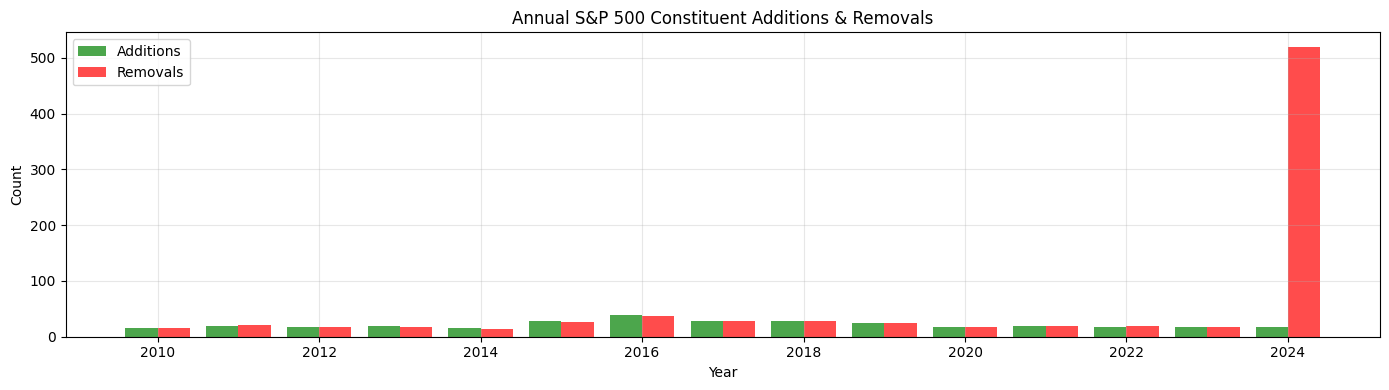

In [19]:
# How many companies entered/exited S&P 500 each year?
entries = constituents.copy()
entries['year_in'] = entries['start_date'].dt.year
entries['year_out'] = entries['end_date'].dt.year

by_year = (
    entries.groupby('year_in').size().rename('additions')
    .to_frame()
    .join(entries[~entries['still_active']].groupby('year_out').size().rename('removals'))
    .fillna(0).astype(int)
    .loc[2010:2025]
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(by_year.index - 0.2, by_year['additions'], width=0.4, label='Additions', color='green', alpha=0.7)
ax.bar(by_year.index + 0.2, by_year['removals'], width=0.4, label='Removals', color='red', alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.set_title('Annual S&P 500 Constituent Additions & Removals')
ax.legend()
plt.tight_layout()
plt.show()

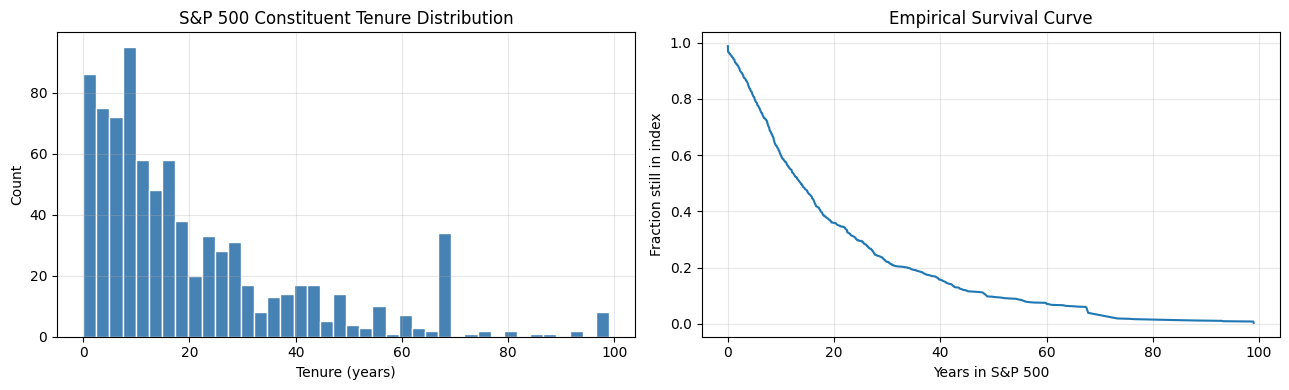

Median tenure: 13.7 years
Mean tenure:   20.6 years


In [20]:
# How long do companies stay in the S&P 500? (tenure distribution)
exited = constituents[~constituents['still_active']].copy()
exited['tenure_years'] = (exited['end_date'] - exited['start_date']).dt.days / 365.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.hist(exited['tenure_years'], bins=40, edgecolor='white', color='steelblue')
ax1.set_xlabel('Tenure (years)')
ax1.set_ylabel('Count')
ax1.set_title('S&P 500 Constituent Tenure Distribution')

# Fraction surviving each year (Kaplan-Meier style)
tenure_sorted = exited['tenure_years'].sort_values()
survival = 1 - (tenure_sorted.rank() / len(tenure_sorted))
ax2.plot(tenure_sorted, survival)
ax2.set_xlabel('Years in S&P 500')
ax2.set_ylabel('Fraction still in index')
ax2.set_title('Empirical Survival Curve')
plt.tight_layout()
plt.show()

print(f'Median tenure: {exited["tenure_years"].median():.1f} years')
print(f'Mean tenure:   {exited["tenure_years"].mean():.1f} years')

## 7. Feature Correlation & Signal Prep

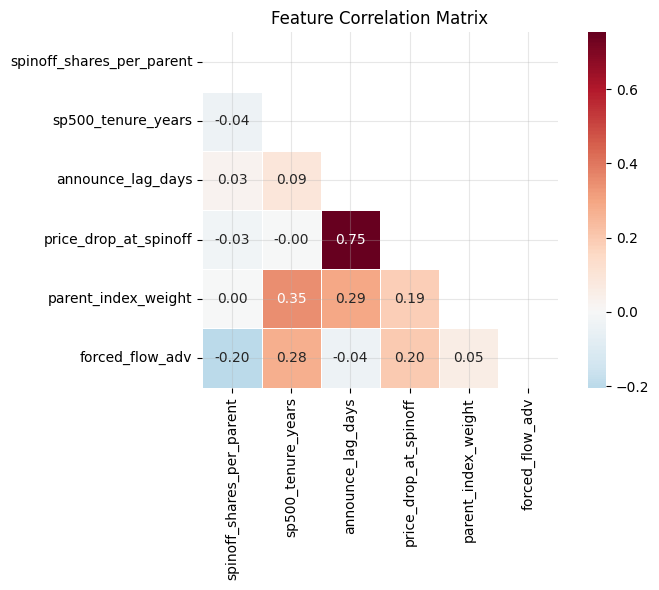

In [21]:
# Numeric feature correlation matrix
numeric_features = ['spinoff_shares_per_parent', 'sp500_tenure_years',
                    'announce_lag_days', 'price_drop_at_spinoff',
                    'parent_index_weight', 'forced_flow_adv']
available = [c for c in numeric_features if c in events.columns]
feat_df = events[available].dropna(how='all')

if len(feat_df) > 2 and len(available) > 1:
    corr = feat_df.corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, ax=ax, square=True, linewidths=0.5)
    ax.set_title('Feature Correlation Matrix')
    plt.tight_layout()
    plt.show()
else:
    print('[!] Not enough data for correlation matrix yet')

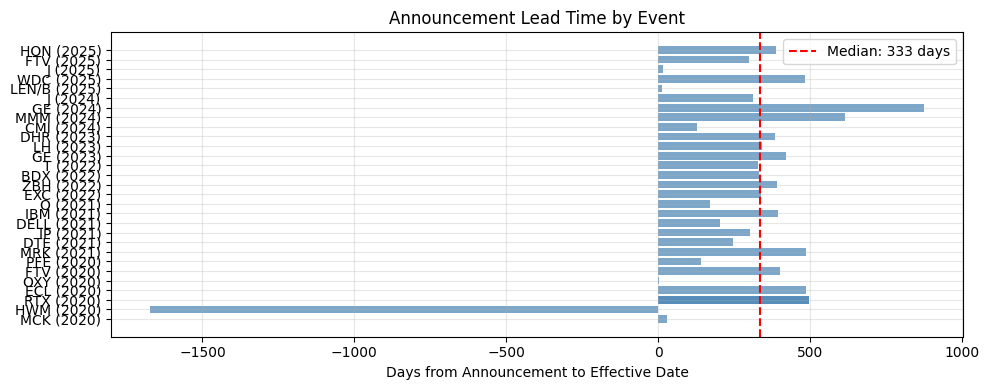

In [22]:
# Announce lag distribution — longer lag = more time for market to price in?
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(events['parent_ticker'] + ' (' + events['effective_date'].dt.year.astype(str) + ')',
        events['announce_lag_days'], color='steelblue', alpha=0.7)
ax.axvline(events['announce_lag_days'].median(), color='red', linestyle='--',
           label=f'Median: {events["announce_lag_days"].median():.0f} days')
ax.set_xlabel('Days from Announcement to Effective Date')
ax.set_title('Announcement Lead Time by Event')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Volume Signature Around Spinoff

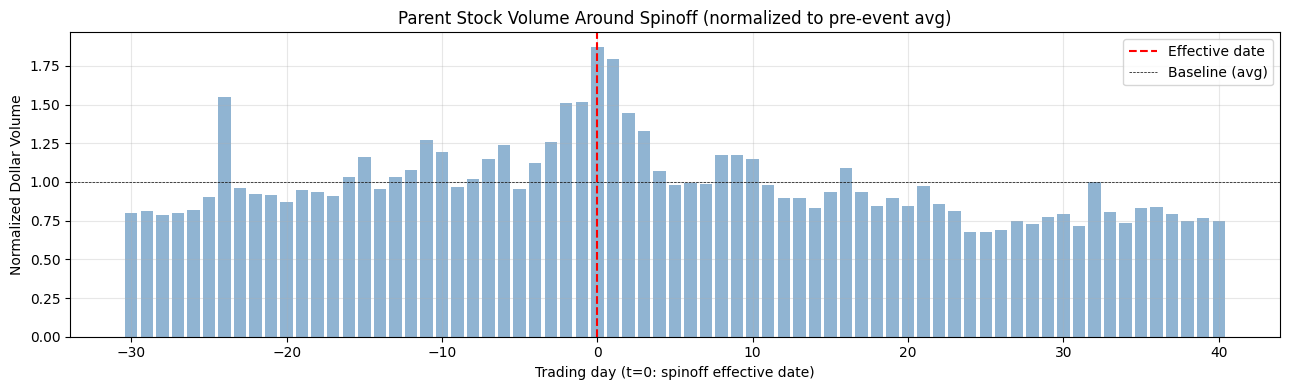

In [23]:
if len(all_windows):
    # Normalized volume around spinoff (vol / avg vol in [-30, -5])
    def normalize_volume(group):
        baseline = group[group['t'].between(-30, -5)]['dollar_vol'].mean()
        if baseline > 0:
            group['norm_vol'] = group['dollar_vol'] / baseline
        else:
            group['norm_vol'] = np.nan
        return group

    vol_windows = (
        all_windows[all_windows['t'].between(-30, 40)]
        .groupby(['parent_ticker', 'effective_date'], group_keys=False)
        .apply(normalize_volume)
    )

    avg_vol = vol_windows.groupby('t')['norm_vol'].mean()

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.bar(avg_vol.index, avg_vol.values, color='steelblue', alpha=0.6, width=0.8)
    ax.axvline(0, color='red', linestyle='--', label='Effective date')
    ax.axhline(1, color='black', lw=0.5, linestyle='--', label='Baseline (avg)')
    ax.set_xlabel('Trading day (t=0: spinoff effective date)')
    ax.set_ylabel('Normalized Dollar Volume')
    ax.set_title('Parent Stock Volume Around Spinoff (normalized to pre-event avg)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('[!] Need parent CRSP price data — run: python repull_data.py')

## 9. Summary — Key Findings for Signal Construction

Fill in after running with full data:

In [24]:
print('=== DATA COVERAGE ===')
print(f"Spinoff events:               {len(events)}")
print(f"Events with CRSP prices:      {events['has_price_data'].sum()} / {len(events)}")
print(f"Events with forced-flow est:  {events.get('forced_flow_usd', pd.Series()).notna().sum()} / {len(events)}")
print(f"CRSP daily rows:              {len(crsp):,}")
print(f"Unique permnos in CRSP:       {crsp['permno'].nunique()}")
print(f"S&P 500 constituent records:  {len(constituents):,}")
print(f"Unique companies (permno):    {constituents[id_col].nunique()}")
if passive_aum is not None:
    print(f"Passive AUM months:           {len(passive_aum)}")
else:
    print("Passive AUM:                  NOT YET AVAILABLE")

print()
print('=== CANDIDATE SIGNALS ===')
print('1. forced_flow_adv  — expected forced selling in days of ADV')
print('2. parent_index_weight — parent weight in S&P 500 at spinoff')
print('3. announce_lag_days — lead time from announcement to effective date')
print('4. price_drop_at_spinoff — price change at effective date (ex-dividend style)')
print('5. sp500_tenure_years — how long parent has been in index')
print('6. spinoff_shares_per_parent — distribution ratio')

=== DATA COVERAGE ===
Spinoff events:               30
Events with CRSP prices:      30 / 30
Events with forced-flow est:  30 / 30
CRSP daily rows:              2,519,394
Unique permnos in CRSP:       826
S&P 500 constituent records:  828
Unique companies (permno):    817
Passive AUM months:           195

=== CANDIDATE SIGNALS ===
1. forced_flow_adv  — expected forced selling in days of ADV
2. parent_index_weight — parent weight in S&P 500 at spinoff
3. announce_lag_days — lead time from announcement to effective date
4. price_drop_at_spinoff — price change at effective date (ex-dividend style)
5. sp500_tenure_years — how long parent has been in index
6. spinoff_shares_per_parent — distribution ratio
